Data source:
https://www.youtube.com/watch?v=fcoVlBIYD54(신박AI)

In [602]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [604]:
class MLP:
    def __init__ (self, input_size, hidden_size, output_size):
        self.input_size = input_size 
        self.hidden_size = hidden_size 
        self.output_size = output_size 

        self.w1_2_3_4 = np.random.random((self.input_size, self.hidden_size))
        self.w5_6 = np.random.random((self.hidden_size, self.output_size))

    def sigmoid(self, x):
        return 1 / (1+np.exp(-x))

    def forward (self, X):
        self.z1_2 = np.dot(X, self.w1_2_3_4) # 1x2
        self.h = self.sigmoid(self.z1_2) # 1x2
        self.z3 = np.dot(self.h, self.w5_6) # 1x1
        self.o = self.sigmoid(self.z3) # 1x1
        return self.o

    def mse_loss(self, y_true, y_pred):
        return np.mean( (y_true - y_pred) **2 ) 

    def backward (self, X, y , y_pred, learning_rate):
        dc_do1 = -2 * ( y - y_pred) 
        do1_dz3 = y_pred * ( 1 - y_pred )
        
        dz3_dw5_6 = self.h
        
        dc_dw5_6 = dc_do1 * do1_dz3 * dz3_dw5_6 # 1 x 2
        self.w5_6 = self.w5_6 + learning_rate * -dc_dw5_6.T # 2 x 1
         
        dc_dw1_2_3_4 = dc_do1 * do1_dz3 * np.dot(self.w5_6 * (self.h * (1 - self.h)).T, X)

        self.w1_2_3_4 = self.w1_2_3_4 + learning_rate * -dc_dw1_2_3_4.T 

    def train(self, X_train, y_train, epochs, learning_rate):
        for epoch in range (epochs):
            for i in range(len(X_train)):
                y_pred = self.forward (   X_train[i]  )
                loss = self.mse_loss ( y_train[i] , y_pred )
                self.backward( X_train[i] , y_train[i], y_pred, learning_rate)
            if np.mod(epoch,100) == 0:
                print('epoch=', epoch, 'loss=', loss)


In [606]:
mlp = MLP(input_size=2, hidden_size=2, output_size=1)
mlp.train(X_train, y_train, epochs=1000, learning_rate=0.1)


epoch= 0 loss= 0.20701402126916246
epoch= 100 loss= 0.2662207237071934
epoch= 200 loss= 0.25224740865330597
epoch= 300 loss= 0.23415899264474632
epoch= 400 loss= 0.2222248127489559
epoch= 500 loss= 0.21666789232882316
epoch= 600 loss= 0.21399747163826566
epoch= 700 loss= 0.2125384081088556
epoch= 800 loss= 0.21164778472718793
epoch= 900 loss= 0.21105719712604243


Epoch 100/3500, Loss: 0.2499
Epoch 200/3500, Loss: 0.2498
Epoch 300/3500, Loss: 0.2498
Epoch 400/3500, Loss: 0.2497
Epoch 500/3500, Loss: 0.2497
Epoch 600/3500, Loss: 0.2496
Epoch 700/3500, Loss: 0.2496
Epoch 800/3500, Loss: 0.2495
Epoch 900/3500, Loss: 0.2494
Epoch 1000/3500, Loss: 0.2494
Epoch 1100/3500, Loss: 0.2493
Epoch 1200/3500, Loss: 0.2492
Epoch 1300/3500, Loss: 0.2490
Epoch 1400/3500, Loss: 0.2488
Epoch 1500/3500, Loss: 0.2484
Epoch 1600/3500, Loss: 0.2477
Epoch 1700/3500, Loss: 0.2467
Epoch 1800/3500, Loss: 0.2448
Epoch 1900/3500, Loss: 0.2415
Epoch 2000/3500, Loss: 0.2361
Epoch 2100/3500, Loss: 0.2279
Epoch 2200/3500, Loss: 0.2176
Epoch 2300/3500, Loss: 0.2071
Epoch 2400/3500, Loss: 0.1981
Epoch 2500/3500, Loss: 0.1908
Epoch 2600/3500, Loss: 0.1849
Epoch 2700/3500, Loss: 0.1795
Epoch 2800/3500, Loss: 0.1738
Epoch 2900/3500, Loss: 0.1669
Epoch 3000/3500, Loss: 0.1577
Epoch 3100/3500, Loss: 0.1411
Epoch 3200/3500, Loss: 0.1119
Epoch 3300/3500, Loss: 0.0819
Epoch 3400/3500, Lo

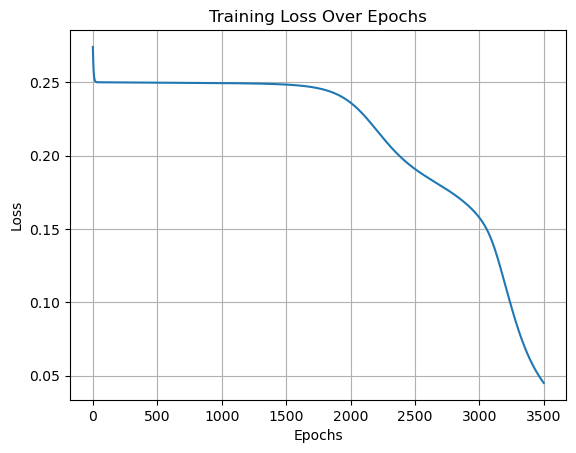

In [611]:
import numpy as np
import matplotlib.pyplot as plt

class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        np.random.seed(1004)  # 재현 가능성을 위한 랜덤 시드 설정
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # Xavier 초기화를 이용한 가중치 초기화
        limit_1 = np.sqrt(2. / (self.input_size + self.hidden_size))
        limit_2 = np.sqrt(2. / (self.hidden_size + self.output_size))

        # 가중치(W)와 편향(b) 초기화
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * limit_1
        self.W2 = np.random.randn(self.hidden_size, self.output_size) * limit_2
        self.b1 = np.zeros((1, self.hidden_size))  # 은닉층 편향
        self.b2 = np.zeros((1, self.output_size))  # 출력층 편향

    def sigmoid(self, x):
        # 오버플로우 방지 및 안정적인 sigmoid 함수 구현
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def sigmoid_derivative(self, x):
        # 시그모이드 함수의 미분
        return x * (1 - x)

    def forward(self, X):
        # 순전파: 입력 -> 은닉층 -> 출력층
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2

    def mse_loss(self, y_true, y_pred):
        # 평균 제곱 오차 (MSE) 손실 함수
        return np.mean((y_true - y_pred) ** 2)

    def backward(self, X, y, y_pred, learning_rate):
        # 역전파: 그래디언트 계산 및 가중치 업데이트
        error_output = y_pred - y
        d_output = error_output * self.sigmoid_derivative(y_pred)

        # W2와 b2 업데이트
        dc_dw2 = np.dot(self.A1.T, d_output)
        dc_db2 = np.sum(d_output, axis=0, keepdims=True)
        self.W2 -= learning_rate * dc_dw2
        self.b2 -= learning_rate * dc_db2

        # 은닉층으로의 오류 전파
        error_hidden = np.dot(d_output, self.W2.T)
        d_hidden = error_hidden * self.sigmoid_derivative(self.A1)

        # W1과 b1 업데이트
        dc_dw1 = np.dot(X.T, d_hidden)
        dc_db1 = np.sum(d_hidden, axis=0, keepdims=True)
        self.W1 -= learning_rate * dc_dw1
        self.b1 -= learning_rate * dc_db1

    def train(self, X_train, y_train, epochs, learning_rate, verbose=True):
        # 훈련 루프
        loss_history = []
        for epoch in range(epochs):
            # 순전파 및 손실 계산
            y_pred = self.forward(X_train)
            loss = self.mse_loss(y_train, y_pred)
            loss_history.append(loss)

            # 역전파 및 가중치 업데이트
            self.backward(X_train, y_train, y_pred, learning_rate)

            # 주기적으로 손실 값 출력
            if verbose and epoch % 100 == 0 and epoch != 0:
                print(f"Epoch {epoch}/{epochs}, Loss: {loss:.4f}")

        return loss_history

# XOR 문제를 위한 데이터셋 (무작위 이진 입력)
X_train = np.random.randint(0, 2, (100, 2))
y_train = (X_train[:, 0] != X_train[:, 1]).astype(int).reshape(-1, 1)

# MLP 모델 초기화 및 훈련
mlp = MLP(input_size=2, hidden_size=2, output_size=1)
loss_history = mlp.train(X_train, y_train, epochs=3500, learning_rate=0.01)

# 손실 값 시각화
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()


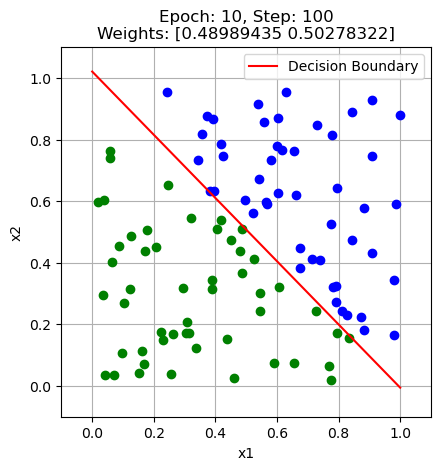

In [613]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from time import sleep

# Define the step function
def step_function(x):
    if x < thres:
        return 0
    else:
        return 1

# Generate training data
def gen_training_data(data_point):
    x1 = np.random.random(data_point)
    x2 = np.random.random(data_point)
    y = ((x1 + x2) > 1).astype(int)
    training_set = [((x1[i], x2[i]), y[i]) for i in range(len(x1))]
    return training_set

# Parameters
thres = 0.5
w = np.array([0.3, 0.9])  # Initial weights
lr = 0.1  # Learning rate
data_point = 100
epoch = 10

# Generate the training dataset
training_set = gen_training_data(data_point)

# Plot the initial training data
plt.figure(figsize=(6, 6))
plt.ylim(-0.1, 1.1)
plt.xlim(-0.1, 1.1)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')

for x, y in training_set:
    if y == 1:
        plt.plot(x[0], x[1], 'bo')
    else:
        plt.plot(x[0], x[1], 'go')
plt.show()

# Learning starts!
xx = np.linspace(0, 1, 50)

plt.figure(figsize=(6, 6))
plt.ylim(-0.1, 1.1)
plt.xlim(-0.1, 1.1)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')

for i in range(epoch):
    for cnt, (x, y) in enumerate(training_set):
        # Clear output for real-time visualization
        clear_output(wait=True)

        # Compute the weighted sum (u) and the error
        u = np.sum(x * w)
        error = y - step_function(u)

        # Update the weights
        for index, value in enumerate(x):
            w[index] += lr * error * value

        # Clear figure and plot points up to the current one
        plt.clf()
        plt.ylim(-0.1, 1.1)
        plt.xlim(-0.1, 1.1)
        ax = plt.gca()
        ax.set_aspect('equal', adjustable='box')

        # Plot all points (up to the current one)
        for xs, ys in training_set[:cnt+1]:
            if ys == 1:
                plt.plot(xs[0], xs[1], 'bo')
            else:
                plt.plot(xs[0], xs[1], 'go')

        # Plot the decision boundary
        yy = -w[1] / w[0] * xx + thres / w[0]  # w[0] * yy + w[1] * xx = thres
        plt.plot(xx, yy, 'r-', label="Decision Boundary")

        plt.title(f"Epoch: {i+1}, Step: {cnt+1}\nWeights: {w}")
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.legend()
        plt.grid(True)
        plt.pause(0.01)  # Pause to visualize updates
        sleep(0.01)

plt.show()
